In [48]:
# Standard library
import os
import re
import sys
import warnings
from pathlib import Path

# Third-party - Data and scientific computing
import contextily as cx
import geopandas as gpd
import igraph as ig
import numpy as np
import pandas as pd
from pyproj import Geod
from tqdm import tqdm

# Shapely-specific imports for spatial analysis
import shapely
from shapely import STRtree
from shapely.geometry import LineString, MultiLineString, Point
from shapely.ops import nearest_points, snap

# Matplotlib-specific imports for figures
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, ListedColormap, Normalize
from matplotlib.lines import Line2D
from matplotlib.patches import Patch, Rectangle
from matplotlib.ticker import FuncFormatter, MultipleLocator
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Suppress warnings
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action="ignore", category=RuntimeWarning)

In [49]:
BASE_DIR = Path.cwd().parent
data_path = BASE_DIR / "input_files"
figure_path = BASE_DIR / "figures"
intermediate_path = BASE_DIR / 'intermediate_results'
results_path = BASE_DIR / 'results'
accessibility_analysis_path = BASE_DIR / 'accessibility_analysis'

In [50]:
gdf_hazards = gpd.read_parquet(intermediate_path / "main_network_hazard_exposure.parquet") 
base_network = gpd.read_parquet(intermediate_path / 'PERS_directed_final.parquet')

In [51]:
# Is flood_depth corrected or uncorrected?
print(f"Roads with flood_depth > 0: {(gdf_hazards['max_depth'] > 0).sum()}")
print(f"Max flood_depth: {gdf_hazards['max_depth'].max():.2f}")
print(gdf_hazards['max_depth'].describe())

# How many should have flood_depth > 0 after correction?
# From our earlier analysis: 837 roads on the PERS network

Roads with flood_depth > 0: 756
Max flood_depth: 53.80
count    756.000000
mean       3.871960
std        4.693633
min        0.002000
25%        0.922000
50%        2.424000
75%        5.269000
max       53.805000
Name: max_depth, dtype: float64


In [52]:
# Load all critical roads (includes roads with and without hazard exposure)
gdf_all_critical = gpd.read_parquet(intermediate_path / "criticality_results.parquet"
).to_crs(gdf_hazards.crs)

for col in ['oznaka_deo', 'oznaka_put', 'pocetna_st', 'zavrsna_st']:
    print(f"\n--- {col} ---")
    print(f"  gdf_all_critical: {gdf_all_critical[col].nunique()} unique / {len(gdf_all_critical)} total, nulls: {gdf_all_critical[col].isna().sum()}")
    print(f"  gdf_hazards:      {gdf_hazards[col].nunique()} unique / {len(gdf_hazards)} total, nulls: {gdf_hazards[col].isna().sum()}")
# Merge so that roads only in the criticality results are also included.
# A left join on gdf_all_critical ensures no critical road is dropped,
# while hazard columns are NaN for roads with no hazard exposure.
# Keep only the hazard-specific columns from gdf_hazards to avoid conflicts
hazard_only_cols = [col for col in gdf_hazards.columns 
                    if col not in gdf_all_critical.columns or col == "geometry"]

crs = gdf_all_critical.crs  # save before the join

gdf_all_critical = gdf_all_critical.drop(columns=["index_right"], errors="ignore")
gdf_hazards = gdf_hazards.drop(columns=["index_right"], errors="ignore")            


gdf_hazards_joined = gpd.sjoin(
    gdf_all_critical,
    gdf_hazards[hazard_only_cols].assign(_hazard_len=gdf_hazards.geometry.length),
    how="left",
    predicate="intersects",
).drop(columns=["index_right"], errors="ignore")

gdf_hazards = (
    gdf_hazards_joined
    .sort_values("_hazard_len", ascending=False)
    .groupby(level=0)
    .first()
    .drop(columns="_hazard_len")
)

# Restore geodataframe with correct geometry and CRS
gdf_hazards = gpd.GeoDataFrame(gdf_hazards, geometry="geometry", crs=crs)

assert len(gdf_hazards) == len(gdf_all_critical)


--- oznaka_deo ---
  gdf_all_critical: 1720 unique / 3135 total, nulls: 801
  gdf_hazards:      1007 unique / 1085 total, nulls: 3

--- oznaka_put ---
  gdf_all_critical: 323 unique / 3135 total, nulls: 9
  gdf_hazards:      286 unique / 1085 total, nulls: 0

--- pocetna_st ---
  gdf_all_critical: 1225 unique / 3135 total, nulls: 801
  gdf_hazards:      752 unique / 1085 total, nulls: 3

--- zavrsna_st ---
  gdf_all_critical: 1665 unique / 3135 total, nulls: 835
  gdf_hazards:      987 unique / 1085 total, nulls: 15


In [53]:
hospital_exposed_edges = gpd.read_parquet(intermediate_path / 'hospital_impacts.parquet').to_crs(gdf_hazards.crs)
factory_exposed_edges = gpd.read_parquet(intermediate_path / 'factory_impacts.parquet').to_crs(gdf_hazards.crs)
police_exposed_edges = gpd.read_parquet(intermediate_path / 'police_impacts.parquet').to_crs(gdf_hazards.crs)
fire_exposed_edges = gpd.read_parquet(intermediate_path / 'fire_impacts.parquet').to_crs(gdf_hazards.crs)
border_exposed_edges = gpd.read_parquet(intermediate_path / 'road_impacts.parquet').to_crs(gdf_hazards.crs)
port_exposed_edges = gpd.read_parquet(intermediate_path / 'port_impacts.parquet').to_crs(gdf_hazards.crs)
railway_exposed_edges = gpd.read_parquet(intermediate_path / 'rail_impacts.parquet').to_crs(gdf_hazards.crs)

future_flood_change_rp =  gpd.read_parquet(intermediate_path / 'Future Floods change in RP.parquet').to_crs(gdf_hazards.crs)
future_rainfall_change =  gpd.read_parquet(intermediate_path / 'change in maximum daily precipitation rcp 85 period 2.parquet').to_crs(gdf_hazards.crs)

In [54]:
def add_impact_column(base_gdf, edges_gdf, impact_col_name, predicate="intersects", agg="mean", col_to_focus = 'travel_time_impact'):
    """
    Spatially join edges to base_gdf, aggregate travel_time_impact per base index, and add as a new column.
    - predicate: 'intersects', 'within', 'contains', 'touches' (choose based on geometry semantics)
    - agg: 'mean', 'max', 'min', 'median' etc.
    """
    # Keep only needed columns to avoid bloat
    edges = edges_gdf[[col_to_focus, 'geometry']].copy()

    # Spatial join (left frame is base), this creates potential many-to-one matches
    joined = base_gdf.sjoin(edges, how='left', predicate=predicate)

    # Aggregate per left index (hazard_id)
    # Note: joined.index is the left index; the sjoin adds right index as 'index_right'
    agg_series = joined.groupby(joined.index)[col_to_focus].agg(agg)

    # Attach to base_gdf with a clear name
    base_gdf[impact_col_name] = agg_series.reindex(base_gdf.index)

    return base_gdf

# Add each impact column (choose your aggregator: 'mean' or 'max')
gdf_hazards = add_impact_column(gdf_hazards, hospital_exposed_edges, 'hospital_delay', predicate='intersects', agg='mean')
gdf_hazards = add_impact_column(gdf_hazards, factory_exposed_edges,  'factory_delay',  predicate='intersects', agg='mean')
gdf_hazards = add_impact_column(gdf_hazards, police_exposed_edges,   'police_delay',   predicate='intersects', agg='mean')
gdf_hazards = add_impact_column(gdf_hazards, fire_exposed_edges,     'fire_delay',     predicate='intersects', agg='mean')
gdf_hazards = add_impact_column(gdf_hazards, port_exposed_edges,  'port_delay',  predicate='intersects', agg='mean')
gdf_hazards = add_impact_column(gdf_hazards, border_exposed_edges,   'border_delay',   predicate='intersects', agg='mean')
gdf_hazards = add_impact_column(gdf_hazards, railway_exposed_edges,     'railway_delay',     predicate='intersects', agg='mean')
gdf_hazards = add_impact_column(gdf_hazards, future_flood_change_rp,   'future_flood_change',   predicate='intersects', agg='mean',col_to_focus='rp30_mean')
gdf_hazards = add_impact_column(gdf_hazards, future_rainfall_change,     'future_rainfall_change',     predicate='intersects', agg='mean',col_to_focus='max_rx1day_pct')

In [55]:
# Load future pavement temperatures (with UHI + climate change)
roads_temp = gpd.read_parquet(intermediate_path / 'PERS_directed_final_with_temp_uhi.parquet')

gdf_hazards = gdf_hazards.drop(columns=['max_pavement_temp'], errors='ignore')

gdf_hazards = gdf_hazards.merge(
    roads_temp[['oznaka_deo', 'smer_gdf1', 'max_temp']].drop_duplicates(['oznaka_deo', 'smer_gdf1']),
    on=['oznaka_deo', 'smer_gdf1'],
    how='left'
).rename(columns={'max_temp': 'max_pavement_temp'})

print(f"Roads with temperature: {gdf_hazards['max_pavement_temp'].notna().sum()} / {len(gdf_hazards)}")
print(gdf_hazards['max_pavement_temp'].describe())

Roads with temperature: 3135 / 3135
count    3135.000000
mean       57.568532
std         2.095495
min        50.416862
25%        56.763496
50%        56.821072
75%        57.594444
max        63.907345
Name: max_pavement_temp, dtype: float64


In [56]:
gdf_hazards = gdf_hazards.drop(columns=['max_pavement_temp'], errors='ignore')

gdf_hazards = gdf_hazards.merge(
    roads_temp[['oznaka_deo', 'smer_gdf1', 'max_temp']].drop_duplicates(['oznaka_deo', 'smer_gdf1']),
    on=['oznaka_deo', 'smer_gdf1'],
    how='left'
).rename(columns={'max_temp': 'max_pavement_temp'})

print(f"Roads with temperature: {gdf_hazards['max_pavement_temp'].notna().sum()} / {len(gdf_hazards)}")
print(gdf_hazards['max_pavement_temp'].describe())

Roads with temperature: 3135 / 3135
count    3135.000000
mean       57.568532
std         2.095495
min        50.416862
25%        56.763496
50%        56.821072
75%        57.594444
max        63.907345
Name: max_pavement_temp, dtype: float64


In [57]:
def clean_data(gdf_hazards: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    """
    Clean a GeoDataFrame of hazard road segments by removing invalid, duplicate,
    and negligibly short entries.

    Cleaning steps applied in order:
        1. Drop rows with missing ``oznaka_deo`` values.
        2. Drop fully identical duplicate rows (including geometry).
        3. Drop duplicate rows based on non-geometry columns only.
        4. Drop short segments (road_length < 0.05 km) where ``oznaka_deo``
           appears more than once, provided at least one other row in that group
           would remain — ensuring no unique ``oznaka_deo`` entry is lost.

    Progress is printed to stdout after each step.

    Args:
        gdf_hazards: Input GeoDataFrame containing road hazard segments.
                     Expected to have columns ``oznaka_deo`` (road section identifier)
                     and ``road_length`` (segment length in km).

    Returns:
        Cleaned GeoDataFrame with invalid, duplicate, and negligibly short
        segments removed.
    """
    print(f"Rows before cleaning: {len(gdf_hazards)}")

    gdf_hazards = gdf_hazards.dropna(subset=["oznaka_deo"])
    print(f"Rows after dropping invalid oznaka_deo: {len(gdf_hazards)}")

    gdf_hazards = gdf_hazards.drop_duplicates()
    print(f"Rows after dropping exact duplicates (including geometry): {len(gdf_hazards)}")

    non_geom_cols = [col for col in gdf_hazards.columns if col != "geometry"]
    gdf_hazards = gdf_hazards.drop_duplicates(subset=non_geom_cols)
    print(f"Rows after dropping duplicates (excluding geometry): {len(gdf_hazards)}")

    #drop all segments that are shorter than 50m and that don't cause an oznaka_deo entry to be lost entirely
    duplicated_mask = gdf_hazards["oznaka_deo"].duplicated(keep=False)
    short_mask = gdf_hazards["road_length"] < 0.05

    # For each oznaka_deo, check if at least one row would survive (i.e. has road_length >= threshold)
    has_survivor = gdf_hazards.groupby("oznaka_deo")["road_length"].transform(
        lambda x: (x >= 0.05).any()
    )

    # Only drop if: it's a duplicate oznaka_deo AND it's short AND its group has a survivor
    drop_mask = duplicated_mask & short_mask & has_survivor

    gdf_hazards = gdf_hazards[~drop_mask]
    print(f"Rows after dropping sections with double oznaka_deo that are shorter than 50m: {len(gdf_hazards)}")

    return gdf_hazards


In [58]:
# remove rows from the data that are not relevant
gdf_hazards = clean_data(gdf_hazards)

Rows before cleaning: 3135
Rows after dropping invalid oznaka_deo: 2334
Rows after dropping exact duplicates (including geometry): 2334
Rows after dropping duplicates (excluding geometry): 2334
Rows after dropping sections with double oznaka_deo that are shorter than 50m: 2158


In [59]:
# =============================================================================
# CLIMATE CRITICALITY METRIC - UPDATED METHODOLOGY
# =============================================================================

# Ensure gdf_hazards has a stable index
gdf_hazards = gdf_hazards.copy()
gdf_hazards.index.name = 'section_id'

# -----------------------------------------------------------------------------
# 1. PREPARE DATA - Rename columns to standard names
# -----------------------------------------------------------------------------

gdf_hazards = gdf_hazards.rename(columns={
    'max_depth': 'flood_depth',
    'dužina_sn': 'snow_drift',
    'datum_evid': 'landslide_date',
    'wildfire_susc' : 'wildfire_susceptibility'
    # Add any other renames as needed
})

# Convert landslide_date to binary presence indicator
gdf_hazards['landslide_exposure'] = np.where(
    gdf_hazards['landslide_date'].astype(str).str.len() > 0, 1.0, 0.0
)

# -----------------------------------------------------------------------------
# 2. DEFINE METRIC GROUPS FOR EACH SUB-INDEX
# -----------------------------------------------------------------------------

# Hazard Exposure Sub-Index (H) - 7 metrics
hazard_metrics = [
    'flood_depth',              # F  - Maximum inundation depth (cm)
    'future_rainfall_change',   # R  - Projected % change in extreme rainfall
    'future_flood_change',      # C  - Projected % change in river flood magnitude
    'landslide_exposure',       # L  - Binary landslide exposure
    'snow_drift',               # S  - Length affected by snow drift (km)
    'max_pavement_temp',        # PT - Maximum pavement temperature (°C)
    'wildfire_susceptibility',  # W  - Wildfire susceptibility
]

# National-Scale Travel Disruption Sub-Index (T) - 4 metrics
travel_metrics = [
    'phl',  # Passenger hours lost
    'thl',  # Tonnage hours lost
    'pkl',  # Passenger kilometers lost
    'tkl'   # Tonnage kilometers lost
]

# Local Accessibility Sub-Index (A) - 6 metrics
accessibility_metrics = [
    'hospital_delay',      # HOS - Hospital access delay
    'fire_delay',          # FIR - Fire station access delay
    'police_delay',        # POL - Police station access delay
    'port_delay',          # PRT - Port access delay (agriculture)
    'border_delay',        # BRD - Border crossing delay (agriculture/industry)
    'railway_delay'        # RWY - Railway station access delay (agriculture)
]

# All metrics combined
all_metrics = hazard_metrics + travel_metrics + accessibility_metrics

In [60]:
LOG_TRANSFORM_METRICS = [
    'flood_depth',
    'future_rainfall_change',
    'future_flood_change',
    'snow_drift',
    'max_pavement_temp',
    'phl', 'thl', 'pkl', 'tkl',
    'hospital_delay', 'fire_delay', 'police_delay',
    'factory_delay', 'port_delay', 'border_delay', 'railway_delay',
    # landslide_exposure excluded — binary
    # wildfire_susceptibility excluded — binary
]

In [61]:
print(gdf_hazards['wildfire_susceptibility'].value_counts())

wildfire_susceptibility
1.0    824
Name: count, dtype: int64


In [62]:
# -----------------------------------------------------------------------------
# 3. ENSURE ALL COLUMNS EXIST AND HANDLE MISSING VALUES
# -----------------------------------------------------------------------------

for col in all_metrics:
    if col not in gdf_hazards.columns:
        print(f"Warning: Column '{col}' not found. Creating with zeros.")
        gdf_hazards[col] = 0.0
    # Convert to float and fill NaN with 0
    gdf_hazards[col] = gdf_hazards[col].astype(float).fillna(0.0)


In [63]:
# -----------------------------------------------------------------------------
# 4. LOG TRANSFORM — applied before normalization to heavily skewed metrics
# -----------------------------------------------------------------------------
LOG_TRANSFORM_METRICS = [
    'flood_depth',
    'future_rainfall_change',
    'future_flood_change',
    'snow_drift',
    'max_pavement_temp',
    'phl', 'thl', 'pkl', 'tkl',
    'hospital_delay', 'fire_delay', 'police_delay',
    'factory_delay', 'port_delay', 'border_delay', 'railway_delay',
    # landslide_exposure excluded — binary
    # wildfire_susceptibility excluded — binary
]

# Create working columns with log(x+1) where specified
working_metrics = []
for col in all_metrics:
    if col in LOG_TRANSFORM_METRICS:
        working_col = f"{col}_log"
        gdf_hazards[working_col] = np.log1p(gdf_hazards[col])
        working_metrics.append(working_col)
        print(f"  log(x+1) applied: {col} → {working_col}")
    else:
        working_metrics.append(col)

# Clip future change metrics at 0 (negative = lower risk, not relevant)
for col in ["future_rainfall_change", "future_flood_change"]:
    working_col = f"{col}_log" if col in LOG_TRANSFORM_METRICS else col
    if working_col in gdf_hazards.columns:
        gdf_hazards[working_col] = gdf_hazards[working_col].clip(lower=0)
        print(f"  clipped at 0: {working_col}")

# -----------------------------------------------------------------------------
# 5. MIN-MAX NORMALIZATION FUNCTION
# -----------------------------------------------------------------------------
def safe_minmax_normalize(series):
    s = series.astype(float).fillna(0.0)
    min_val = s.min()
    max_val = s.max()
    if pd.isna(min_val) or pd.isna(max_val) or max_val == min_val:
        return pd.Series(np.zeros(len(s)), index=s.index)
    return (s - min_val) / (max_val - min_val)

# -----------------------------------------------------------------------------
# 6. NORMALIZE ALL METRICS (using working columns — log-transformed where applicable)
# -----------------------------------------------------------------------------
print("Normalizing metrics...")

norm_lookup = {}
for orig_col, work_col in zip(all_metrics, working_metrics):
    norm_col = f"{orig_col}_norm"
    gdf_hazards[norm_col] = safe_minmax_normalize(gdf_hazards[work_col])
    norm_lookup[orig_col] = norm_col
    transformed = " (log)" if work_col != orig_col else ""
    print(f"  {orig_col}{transformed}: min={gdf_hazards[work_col].min():.4f}, max={gdf_hazards[work_col].max():.4f}")

# -----------------------------------------------------------------------------
# 7. COMPUTE SUB-INDICES (Equal weights within each sub-index)
# -----------------------------------------------------------------------------
hazard_norm = [f'{col}_norm' for col in hazard_metrics]
travel_norm = [f'{col}_norm' for col in travel_metrics]
accessibility_norm = [f'{col}_norm' for col in accessibility_metrics]

# H = (1/7) × (F + R + C + L + S + PT + W)
gdf_hazards['H_hazard_exposure'] = gdf_hazards[hazard_norm].mean(axis=1)
print(f"sum hazard exposure: {gdf_hazards['H_hazard_exposure'].sum():.2f}")

# T = (1/4) × (PHL + THL + PKL + TKL)
gdf_hazards['T_travel_disruption'] = gdf_hazards[travel_norm].mean(axis=1)
print(f"sum travel disruption: {gdf_hazards['T_travel_disruption'].sum():.2f}")

# A = (1/7) × (HOS + FIR + POL + FAC + PRT + BRD + RWY)
gdf_hazards['A_local_accessibility'] = gdf_hazards[accessibility_norm].mean(axis=1)
print(f"sum local accessibility: {gdf_hazards['A_local_accessibility'].sum():.2f}")

# -----------------------------------------------------------------------------
# 8. COMPUTE COMBINED CLIMATE CRITICALITY (Equal weights across sub-indices)
# -----------------------------------------------------------------------------
# CC = (1/3) × (H + T + A)
sub_indices = ['H_hazard_exposure', 'T_travel_disruption', 'A_local_accessibility']
gdf_hazards['CC_climate_criticality'] = gdf_hazards[sub_indices].mean(axis=1)

# -----------------------------------------------------------------------------
# 9. CLASSIFY INTO QUINTILES (5 categories based on 20% quantiles)
# -----------------------------------------------------------------------------
def classify_quintiles(series, labels=None):
    if labels is None:
        labels = ['Very Low', 'Low', 'Medium', 'High', 'Very High']
    result = pd.Series(index=series.index, dtype='object')
    is_zero = (series == 0)
    result[is_zero] = 'No criticality'
    non_zeros = series[~is_zero]
    if not non_zeros.empty:
        quintiles = pd.qcut(non_zeros, 5, labels=labels, duplicates='drop')
        result[~is_zero] = quintiles
    return result

gdf_hazards['H_class'] = classify_quintiles(gdf_hazards['H_hazard_exposure'])
gdf_hazards['T_class'] = classify_quintiles(gdf_hazards['T_travel_disruption'])
gdf_hazards['A_class'] = classify_quintiles(gdf_hazards['A_local_accessibility'])
gdf_hazards['CC_class'] = classify_quintiles(gdf_hazards['CC_climate_criticality'])

  log(x+1) applied: flood_depth → flood_depth_log
  log(x+1) applied: future_rainfall_change → future_rainfall_change_log
  log(x+1) applied: future_flood_change → future_flood_change_log
  log(x+1) applied: snow_drift → snow_drift_log
  log(x+1) applied: max_pavement_temp → max_pavement_temp_log
  log(x+1) applied: phl → phl_log
  log(x+1) applied: thl → thl_log
  log(x+1) applied: pkl → pkl_log
  log(x+1) applied: tkl → tkl_log
  log(x+1) applied: hospital_delay → hospital_delay_log
  log(x+1) applied: fire_delay → fire_delay_log
  log(x+1) applied: police_delay → police_delay_log
  log(x+1) applied: port_delay → port_delay_log
  log(x+1) applied: border_delay → border_delay_log
  log(x+1) applied: railway_delay → railway_delay_log
  clipped at 0: future_rainfall_change_log
  clipped at 0: future_flood_change_log
Normalizing metrics...
  flood_depth (log): min=0.0000, max=4.0038
  future_rainfall_change (log): min=0.0000, max=3.0826
  future_flood_change (log): min=0.0000, max=4.7743

In [64]:
gdf_hazards

,from_id,to_id,objectid,oznaka_deo,smer_gdf1,kategorija,oznaka_put,oznaka_poc,naziv_poce,oznaka_zav,...,border_delay_norm,railway_delay_norm,H_hazard_exposure,T_travel_disruption,A_local_accessibility,CC_climate_criticality,H_class,T_class,A_class,CC_class
section_id,,,,,,,,,,,,,,,,,,,,,
0,5,6,3.0,A1005,D,IA,A1,A102,petlja Subotica sever,A103,...,0.000000,0.0,0.266671,0.000000,0.000000,0.088890,Low,No criticality,No criticality,Very Low
1,8,9,4.0,A1003,D,IA,A1,A101,petlja Horgoš,A102,...,0.000000,0.0,0.188723,0.431922,0.000000,0.206881,Very Low,Very Low,No criticality,Very Low
2,9,10,4.0,A1003,D,IA,A1,A101,petlja Horgoš,A102,...,0.000000,0.0,0.285186,0.705820,0.000000,0.330335,Low,High,No criticality,Medium
3,11,5,4.0,A1003,D,IA,A1,A101,petlja Horgoš,A102,...,0.000000,0.0,0.261383,0.000000,0.000000,0.087128,Very Low,No criticality,No criticality,Very Low
4,12,13,5.0,A1023,D,IA,A1,A111,petlja Novi Sad sever,A112,...,0.000000,0.0,0.356711,0.663386,0.000000,0.340032,Medium,High,No criticality,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3126,620,619,340.0,01405,O,IB,14,1404,Ralja (put 156),M701,...,0.000000,0.0,0.290192,0.496863,0.000000,0.262352,Low,Very Low,No criticality,Very Low
3127,1015,1014,793.0,03915,O,IB,39,3915,Lebane (Krivača),3916,...,0.308644,0.0,0.638438,0.621437,0.051441,0.437105,Very High,Medium,Very Low,Very High
3128,1056,622,865.0,12903,O,IIA,129,1313,Perlez (Kovačica),12901,...,0.000000,0.0,0.376293,0.430231,0.000000,0.268841,Medium,Very Low,No criticality,Very Low


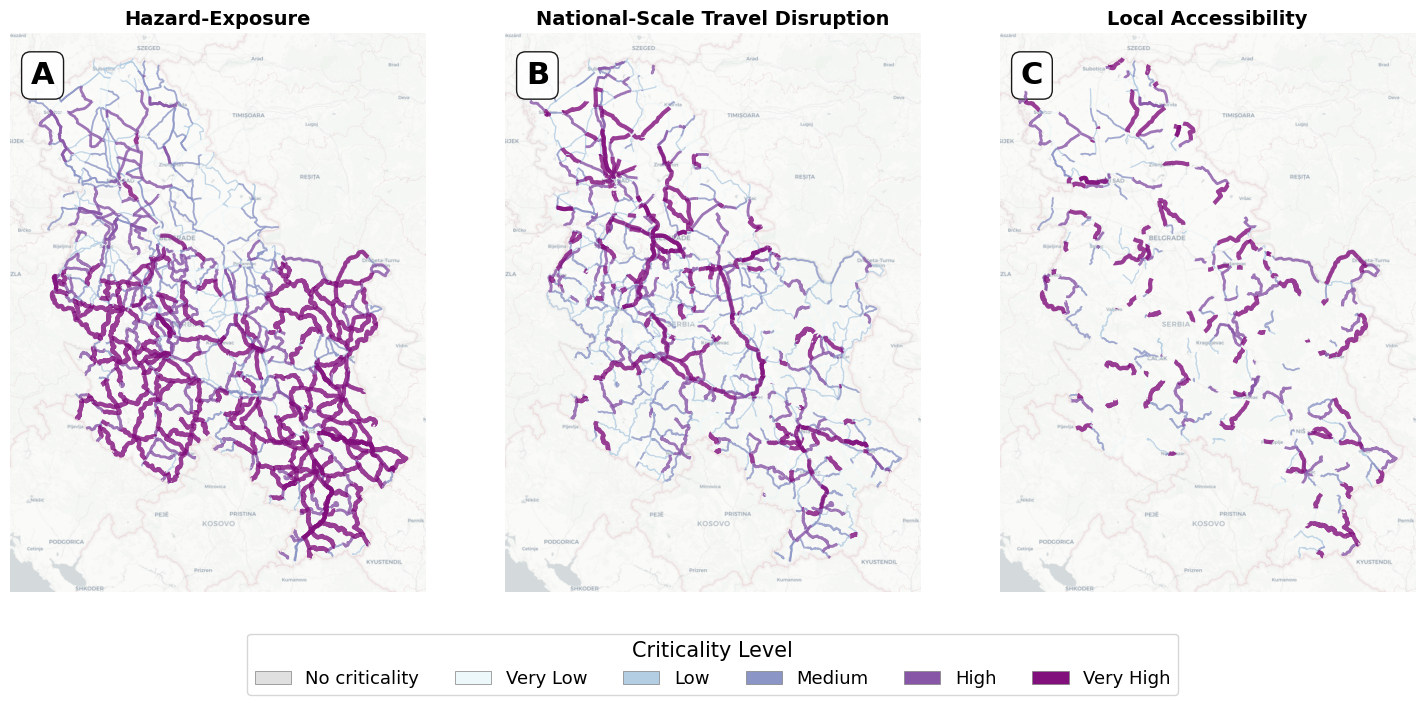

In [65]:
# =============================================================================
# 2. Configuration: Colors, Labels, and Widths
# =============================================================================
class_cols = ['H_class','T_class','A_class']
labels = ['No criticality', 'Very Low', 'Low', 'Medium', 'High', 'Very High']
colors = ['#e0e0e0', '#edf8fb','#b3cde3','#8c96c6','#8856a7','#810f7c']
color_map = dict(zip(labels, colors))

width_mapping = {
    'No criticality': 0.2,
    'Very Low': 0.6,
    'Low': 0.9,
    'Medium': 1.3,
    'High': 2.0,
    'Very High': 3.0
}

# Ensure CRS is Web Mercator for contextily
gdf_hazards = gdf_hazards.to_crs(epsg=3857)

# =============================================================================
# 4. Plotting Function and Figure Generation
# =============================================================================

def plot_panel(ax, gdf, class_col, letter, title):
    # Optional: Plot background network if you have one
    # base_network.plot(ax=ax, linewidth=0.1, color='lightgrey', alpha=0.5)
    
    # Plot each category in specific order (lowest to highest) 
    # so high criticality is on top
    for cat in labels:
        subset = gdf[gdf[class_col] == cat]
        if not subset.empty:
            subset.plot(
                ax=ax, 
                color=color_map[cat], 
                linewidth=width_mapping[cat],
                alpha=0.8 if cat != 'No criticality' else 0.4,
                zorder=labels.index(cat) # Higher criticality on top
            )
    
    # Add Basemap
    cx.add_basemap(ax, source=cx.providers.CartoDB.Positron, attribution=False)
    
    # UI Elements
    ax.axis('off')
    ax.text(0.05, 0.95, letter, transform=ax.transAxes, fontsize=22, 
            fontweight='bold', verticalalignment='top',
            bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.9))
    ax.set_title(title, fontsize=14,fontweight='bold')

# Create the figure
fig, axes = plt.subplots(1, 3, figsize=(15, 7))

titles = ['Hazard-Exposure', 'National-Scale Travel Disruption', 'Local Accessibility']

# Loop through the axes and classification columns
for i, ax in enumerate(axes):
    plot_panel(axes[i], gdf_hazards, class_cols[i], chr(65+i), titles[i])

# =============================================================================
# 5. Shared Legend
# =============================================================================

legend_handles = [
    Patch(facecolor=color_map[lbl], label=lbl, edgecolor='grey', linewidth=0.5)
    for lbl in labels
]

fig.legend(
    handles=legend_handles,
    title='Criticality Level',
    loc='lower center',
    bbox_to_anchor=(0.5, 0.02),
    ncol=6,
    fontsize=13,
    title_fontsize=15,
    frameon=True
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.18)

# Save or show
plt.savefig(figure_path / 'criticality_analysis_3panel.png', dpi=300, bbox_inches='tight')
plt.show()

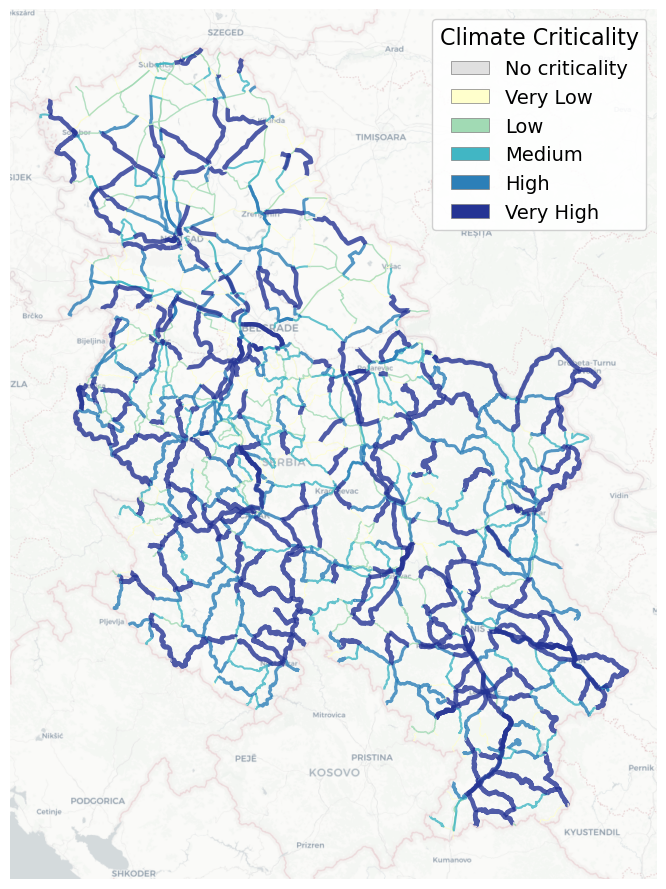

In [66]:
# =============================================================================
# CLIMATE CRITICALITY - SINGLE FIGURE (Mean)
# =============================================================================

# Calculate mean criticality
norm_cols = ['H_hazard_exposure', 'T_travel_disruption', 'A_local_accessibility']
gdf_hazards['criticality_mean'] = gdf_hazards[norm_cols].mean(axis=1)

# Classification function
def classify_quintiles(series, labels=None):
    if labels is None:
        labels = ['Very Low', 'Low', 'Medium', 'High', 'Very High']
    result = pd.Series('No criticality', index=series.index)
    non_zero_mask = series > 0
    non_zeros = series[non_zero_mask]
    
    if not non_zeros.empty:
        bins = pd.qcut(non_zeros, 5, labels=labels, duplicates='drop')
        result[non_zero_mask] = bins.astype(str)
    return result

# Apply classification
gdf_hazards['mean_class'] = classify_quintiles(gdf_hazards['criticality_mean'])

# Ensure Web Mercator for plotting
gdf_hazards = gdf_hazards.to_crs(epsg=3857)

# Visualization configuration
labels = ['No criticality', 'Very Low', 'Low', 'Medium', 'High', 'Very High']
colors = ['#e0e0e0', '#ffffcc', '#a1dab4', '#41b6c4', '#2c7fb8', '#253494']
color_map = dict(zip(labels, colors))
width_mapping = {
    'No criticality': 0.2, 'Very Low': 0.6, 'Low': 1.0, 
    'Medium': 1.5, 'High': 2.2, 'Very High': 3.2
}

# Create single figure
fig, ax = plt.subplots(1, 1, figsize=(7, 9))

# Plot each category
for cat in labels:
    subset = gdf_hazards[gdf_hazards['mean_class'] == cat]
    if not subset.empty:
        subset.plot(
            ax=ax, 
            color=color_map[cat], 
            linewidth=width_mapping[cat],
            alpha=0.8 if cat != 'No criticality' else 0.4,
            zorder=labels.index(cat)
        )

# Add basemap and remove axes
cx.add_basemap(ax, source=cx.providers.CartoDB.Positron, attribution=False)
ax.axis('off')

# Legend
legend_handles = [
    Patch(facecolor=color_map[lbl], label=lbl, edgecolor='grey', linewidth=0.5)
    for lbl in labels
]

ax.legend(
    handles=legend_handles,
    title='Climate Criticality',
    loc='upper right',
    fontsize=14,
    title_fontsize=16,
    frameon=True,
    framealpha=0.9
)

plt.tight_layout()
plt.savefig(figure_path / 'climate_criticality_mean.png', dpi=150, bbox_inches='tight')
plt.show()

In [67]:
gdf_hazards.to_parquet("Serbia_Criticality.parquet")

In [68]:
gdf_hazards

,from_id,to_id,objectid,oznaka_deo,smer_gdf1,kategorija,oznaka_put,oznaka_poc,naziv_poce,oznaka_zav,...,H_hazard_exposure,T_travel_disruption,A_local_accessibility,CC_climate_criticality,H_class,T_class,A_class,CC_class,criticality_mean,mean_class
section_id,,,,,,,,,,,,,,,,,,,,,
0,5,6,3.0,A1005,D,IA,A1,A102,petlja Subotica sever,A103,...,0.266671,0.000000,0.000000,0.088890,Low,No criticality,No criticality,Very Low,0.088890,Very Low
1,8,9,4.0,A1003,D,IA,A1,A101,petlja Horgoš,A102,...,0.188723,0.431922,0.000000,0.206881,Very Low,Very Low,No criticality,Very Low,0.206881,Very Low
2,9,10,4.0,A1003,D,IA,A1,A101,petlja Horgoš,A102,...,0.285186,0.705820,0.000000,0.330335,Low,High,No criticality,Medium,0.330335,Medium
3,11,5,4.0,A1003,D,IA,A1,A101,petlja Horgoš,A102,...,0.261383,0.000000,0.000000,0.087128,Very Low,No criticality,No criticality,Very Low,0.087128,Very Low
4,12,13,5.0,A1023,D,IA,A1,A111,petlja Novi Sad sever,A112,...,0.356711,0.663386,0.000000,0.340032,Medium,High,No criticality,Medium,0.340032,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3126,620,619,340.0,01405,O,IB,14,1404,Ralja (put 156),M701,...,0.290192,0.496863,0.000000,0.262352,Low,Very Low,No criticality,Very Low,0.262352,Very Low
3127,1015,1014,793.0,03915,O,IB,39,3915,Lebane (Krivača),3916,...,0.638438,0.621437,0.051441,0.437105,Very High,Medium,Very Low,Very High,0.437105,Very High
3128,1056,622,865.0,12903,O,IIA,129,1313,Perlez (Kovačica),12901,...,0.376293,0.430231,0.000000,0.268841,Medium,Very Low,No criticality,Very Low,0.268841,Very Low


In [69]:
# =============================================================================
# CLIMATE CRITICALITY - SUMMARY STATISTICS
# =============================================================================

print("="*80)
print("CLIMATE CRITICALITY SUMMARY STATISTICS")
print("="*80)

# Define classification columns
class_cols = ['H_class', 'T_class', 'A_class', 'mean_class']
class_names = ['Hazard Exposure', 'Travel Disruption', 'Local Accessibility', 'Combined Criticality']
index_cols = ['H_hazard_exposure', 'T_travel_disruption', 'A_local_accessibility', 'criticality_mean']

# =============================================================================
# 1. OVERALL DISTRIBUTION BY CRITICALITY CLASS
# =============================================================================

print("\n" + "="*80)
print("1. OVERALL DISTRIBUTION BY CRITICALITY CLASS")
print("="*80)

labels = ['No criticality', 'Very Low', 'Low', 'Medium', 'High', 'Very High']

for class_col, class_name in zip(class_cols, class_names):
    print(f"\n{class_name}:")
    print("-"*50)
    counts = gdf_hazards[class_col].value_counts()
    total = len(gdf_hazards)
    for label in labels:
        if label in counts.index:
            count = counts[label]
            pct = count / total * 100
            print(f"  {label:15s}: {count:5d} ({pct:5.1f}%)")
        else:
            print(f"  {label:15s}: {0:5d} ({0:5.1f}%)")

# =============================================================================
# 2. CRITICALITY BY ROAD CATEGORY
# =============================================================================

print("\n" + "="*80)
print("2. CRITICALITY BY ROAD CATEGORY")
print("="*80)

# Cross-tabulation: Road category vs Criticality class
for class_col, class_name in zip(class_cols, class_names):
    print(f"\n{class_name} by Road Category:")
    print("-"*60)
    
    # Create cross-tab with percentages
    ct = pd.crosstab(gdf_hazards['kategorija'], gdf_hazards[class_col], normalize='index') * 100
    
    # Reorder columns
    ct = ct.reindex(columns=[l for l in labels if l in ct.columns])
    
    print(ct.round(1).to_string())

# =============================================================================
# 3. MEAN CRITICALITY SCORES BY ROAD CATEGORY
# =============================================================================

print("\n" + "="*80)
print("3. MEAN CRITICALITY SCORES BY ROAD CATEGORY")
print("="*80)

road_summary = gdf_hazards.groupby('kategorija').agg({
    'H_hazard_exposure': ['count', 'mean', 'median', 'max'],
    'T_travel_disruption': ['mean', 'median', 'max'],
    'A_local_accessibility': ['mean', 'median', 'max'],
    'criticality_mean': ['mean', 'median', 'max']
}).round(4)

print(road_summary.to_string())

# =============================================================================
# 4. HIGH-TIER vs LOW-TIER ROADS COMPARISON
# =============================================================================

print("\n" + "="*80)
print("4. HIGH-TIER vs LOW-TIER ROADS COMPARISON")
print("="*80)

# Define road tiers
high_tier = ['IA', 'IM', 'IB']  # Motorways and main roads
low_tier = ['IIA', 'IIB']       # Regional roads

gdf_hazards['road_tier'] = np.where(
    gdf_hazards['kategorija'].isin(high_tier), 'High-Tier (IA/IM/IB)',
    np.where(gdf_hazards['kategorija'].isin(low_tier), 'Low-Tier (IIA/IIB)', 'Other')
)

# Compare mean scores
print("\nMean Criticality Scores by Road Tier:")
print("-"*60)
tier_summary = gdf_hazards.groupby('road_tier')[index_cols].mean().round(4)
print(tier_summary.to_string())

# Compare distribution of criticality classes
print("\n\nCombined Criticality Distribution by Road Tier (%):")
print("-"*60)
tier_ct = pd.crosstab(gdf_hazards['road_tier'], gdf_hazards['mean_class'], normalize='index') * 100
tier_ct = tier_ct.reindex(columns=[l for l in labels if l in tier_ct.columns])
print(tier_ct.round(1).to_string())

# Statistical test (if needed)
from scipy import stats
high_tier_scores = gdf_hazards[gdf_hazards['road_tier'] == 'High-Tier (IA/IM/IB)']['criticality_mean']
low_tier_scores = gdf_hazards[gdf_hazards['road_tier'] == 'Low-Tier (IIA/IIB)']['criticality_mean']

if len(high_tier_scores) > 0 and len(low_tier_scores) > 0:
    stat, pvalue = stats.mannwhitneyu(high_tier_scores, low_tier_scores, alternative='two-sided')
    print(f"\nMann-Whitney U test (High-Tier vs Low-Tier):")
    print(f"  U-statistic: {stat:.2f}")
    print(f"  p-value: {pvalue:.6f}")
    print(f"  Significant difference: {'Yes' if pvalue < 0.05 else 'No'}")

# =============================================================================
# 5. TOP 10 MOST CRITICAL SECTIONS (COMBINED)
# =============================================================================

print("\n" + "="*80)
print("5. TOP 10 MOST CRITICAL SECTIONS (Combined Criticality)")
print("="*80)

top_cols = ['oznaka_deo', 'kategorija', 'oznaka_put', 'naziv_poce', 'naziv_zavr',
            'H_hazard_exposure', 'T_travel_disruption', 'A_local_accessibility', 
            'criticality_mean', 'mean_class']
top_cols = [c for c in top_cols if c in gdf_hazards.columns]

top10_combined = gdf_hazards.nlargest(10, 'criticality_mean')[top_cols]
print(top10_combined.to_string())

# =============================================================================
# 6. TOP 5 PER SUB-INDEX
# =============================================================================

print("\n" + "="*80)
print("6. TOP 5 SECTIONS PER SUB-INDEX")
print("="*80)

for index_col, class_name in zip(index_cols[:3], class_names[:3]):
    print(f"\n{class_name} - Top 5:")
    print("-"*60)
    display_cols = ['oznaka_deo', 'kategorija', 'oznaka_put', 'naziv_poce', 'naziv_zavr', index_col]
    display_cols = [c for c in display_cols if c in gdf_hazards.columns]
    print(gdf_hazards.nlargest(5, index_col)[display_cols].to_string())

# =============================================================================
# 7. SHARE OF "HIGH" + "VERY HIGH" BY ROAD CATEGORY
# =============================================================================

print("\n" + "="*80)
print("7. SHARE OF HIGH/VERY HIGH CRITICALITY BY ROAD CATEGORY")
print("="*80)

high_crit_labels = ['High', 'Very High']

for class_col, class_name in zip(class_cols, class_names):
    print(f"\n{class_name}:")
    print("-"*50)
    
    # Calculate % of High + Very High per road category
    high_crit_pct = gdf_hazards.groupby('kategorija').apply(
        lambda x: (x[class_col].isin(high_crit_labels)).sum() / len(x) * 100
    ).sort_values(ascending=False)
    
    print("Road Category | % High/Very High | Count High/Very High | Total")
    for cat in high_crit_pct.index:
        pct = high_crit_pct[cat]
        count_high = gdf_hazards[(gdf_hazards['kategorija'] == cat) & 
                                  (gdf_hazards[class_col].isin(high_crit_labels))].shape[0]
        total = gdf_hazards[gdf_hazards['kategorija'] == cat].shape[0]
        print(f"  {cat:12s} | {pct:14.1f}% | {count_high:20d} | {total}")

# =============================================================================
# 8. CORRELATION BETWEEN SUB-INDICES
# =============================================================================

print("\n" + "="*80)
print("8. CORRELATION BETWEEN SUB-INDICES")
print("="*80)

corr_matrix = gdf_hazards[index_cols].corr()
print(corr_matrix.round(3).to_string())

# =============================================================================
# 9. SUMMARY TABLE FOR TEXT
# =============================================================================

print("\n" + "="*80)
print("9. SUMMARY TABLE FOR TEXT")
print("="*80)

summary_data = []
for cat in gdf_hazards['kategorija'].dropna().unique():
    subset = gdf_hazards[gdf_hazards['kategorija'] == cat]
    n_sections = len(subset)
    
    # % in High/Very High for each sub-index
    pct_H_high = (subset['H_class'].isin(high_crit_labels)).sum() / n_sections * 100
    pct_T_high = (subset['T_class'].isin(high_crit_labels)).sum() / n_sections * 100
    pct_A_high = (subset['A_class'].isin(high_crit_labels)).sum() / n_sections * 100
    pct_CC_high = (subset['mean_class'].isin(high_crit_labels)).sum() / n_sections * 100
    
    summary_data.append({
        'Road Category': cat,
        'N Sections': n_sections,
        '% High/VH Hazard': f"{pct_H_high:.1f}%",
        '% High/VH Travel': f"{pct_T_high:.1f}%",
        '% High/VH Access': f"{pct_A_high:.1f}%",
        '% High/VH Combined': f"{pct_CC_high:.1f}%"
    })

summary_df = pd.DataFrame(summary_data).sort_values('Road Category')
print(summary_df.to_string(index=False))

# =============================================================================
# 10. KEY FINDINGS FOR TEXT
# =============================================================================

print("\n" + "="*80)
print("10. KEY FINDINGS FOR TEXT")
print("="*80)

total_sections = len(gdf_hazards)
high_vh_combined = gdf_hazards['mean_class'].isin(high_crit_labels).sum()
pct_high_vh = high_vh_combined / total_sections * 100

print(f"""
KEY STATISTICS:
- Total road sections analyzed: {total_sections}
- Sections with High/Very High combined criticality: {high_vh_combined} ({pct_high_vh:.1f}%)

ROAD TIER COMPARISON:
- High-tier roads (IA/IM/IB) mean criticality: {high_tier_scores.mean():.4f}
- Low-tier roads (IIA/IIB) mean criticality: {low_tier_scores.mean():.4f}

TOP CRITICAL SECTION:
""")

top1 = gdf_hazards.nlargest(1, 'criticality_mean').iloc[0]
print(f"  Road: {top1.get('oznaka_put', 'N/A')} ({top1.get('kategorija', 'N/A')})")
print(f"  Section: {top1.get('naziv_poce', 'N/A')} → {top1.get('naziv_zavr', 'N/A')}")
print(f"  Combined Criticality Score: {top1['criticality_mean']:.4f}")
print(f"  H: {top1['H_hazard_exposure']:.4f}, T: {top1['T_travel_disruption']:.4f}, A: {top1['A_local_accessibility']:.4f}")

CLIMATE CRITICALITY SUMMARY STATISTICS

1. OVERALL DISTRIBUTION BY CRITICALITY CLASS

Hazard Exposure:
--------------------------------------------------
  No criticality :     0 (  0.0%)
  Very Low       :   432 ( 20.0%)
  Low            :   431 ( 20.0%)
  Medium         :   433 ( 20.1%)
  High           :   430 ( 19.9%)
  Very High      :   432 ( 20.0%)

Travel Disruption:
--------------------------------------------------
  No criticality :    88 (  4.1%)
  Very Low       :   414 ( 19.2%)
  Low            :   414 ( 19.2%)
  Medium         :   414 ( 19.2%)
  High           :   414 ( 19.2%)
  Very High      :   414 ( 19.2%)

Local Accessibility:
--------------------------------------------------
  No criticality :  1681 ( 77.9%)
  Very Low       :    97 (  4.5%)
  Low            :    95 (  4.4%)
  Medium         :    94 (  4.4%)
  High           :    95 (  4.4%)
  Very High      :    96 (  4.4%)

Combined Criticality:
--------------------------------------------------
  No criticality

In [70]:
# Check that the actual values differ even though bin counts are the same
print("Hazard - Very High roads:")
print(gdf_hazards.loc[gdf_hazards['H_class'] == 'Very High', 'H_hazard_exposure'].describe())

print("\nTravel - Very High roads:")
print(gdf_hazards.loc[gdf_hazards['T_class'] == 'Very High', 'T_travel_disruption'].describe())

# Check overlap: are the same roads in Very High for both?
h_vh = set(gdf_hazards.loc[gdf_hazards['H_class'] == 'Very High'].index)
t_vh = set(gdf_hazards.loc[gdf_hazards['T_class'] == 'Very High'].index)
print(f"\nOverlap: {len(h_vh & t_vh)} roads are Very High in BOTH ({len(h_vh & t_vh)/219*100:.1f}%)")

Hazard - Very High roads:
count    432.000000
mean       0.565402
std        0.050584
min        0.490103
25%        0.523032
50%        0.558272
75%        0.606622
max        0.699800
Name: H_hazard_exposure, dtype: float64

Travel - Very High roads:
count    414.000000
mean       0.780780
std        0.044948
min        0.718895
25%        0.745091
50%        0.774013
75%        0.807089
max        0.946236
Name: T_travel_disruption, dtype: float64

Overlap: 45 roads are Very High in BOTH (20.5%)


In [72]:
gdf_hazards.to_excel(results_path / 'Climate_Criticality_PuteviSrbije.xlsx')

In [73]:
gdf_hazards.to_parquet(results_path / 'Climate_Criticality_PuteviSrbije.parquet')
gdf_hazards.to_file(results_path / 'Climate_Criticality_PuteviSrbije.gpkg', driver="GPKG")